In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
import lc_reconstruction_analysis.utils as utils
import lc_reconstruction_analysis.dendritic as dendritic
import lc_reconstruction_analysis.clustering as clustering
import lc_reconstruction_analysis.axon as axon
import lc_reconstruction_analysis.correlation as correlation
%matplotlib inline

In [2]:
# Define path to data
DATA_DIR = Path("/data/")
# Load data frame of cells, and networkx graphs
dataDF, graphs = utils.load_cells(DATA_DIR)

Missing structure dendrite for /data/685221_12_5_24/Complete_annotated/N064-68221-JN.json
Missing structure dendrite for /data/685221_12_5_24/Complete_annotated/N025-685221-PG.json
Missing structure axon for /data/685221_12_5_24/Complete_annotated/N064-685221-JN.json
Missing structure dendrite for /data/685221_12_5_24/Complete_annotated/N051-685221 -YP.json
Missing structure dendrite for /data/648434_12_5_24/Complete_annotated/N024-648434-SS.json
Error finding structures for: N025-685221-PG, dropping from dataframe
Error finding structures for: N064-68221-JN, dropping from dataframe
Error finding structures for: N064-685221-JN, dropping from dataframe
Error finding structures for: N051-685221 -YP, dropping from dataframe
Error finding structures for: N024-648434-SS, dropping from dataframe


In [3]:
# Exclude any neurons that need to be excluded
excludeList = [ # Look like MY cells mistakenly included in LC batch
    "N039-685222-AK",
    "N040-685222-VM",
    "N066-685221-JN",
    "N068-685221-HD",
    "N067-685221-HS"
]

dataDF = dataDF.drop(dataDF[dataDF["Graph"].isin(excludeList)].index)

In [4]:
## Supplement dataDF with MouseLight cells
folderPath = DATA_DIR.joinpath("mouselight_public")
filePaths = [os.path.join(folderPath,fn) for fn in os.listdir(folderPath) if fn.endswith(".json")]
# Load graphs
ml_graphs = utils.load_graphs(filePaths)
# Initiate dataDF
i = 0
datasetDicts = {}
for key, val in ml_graphs.items():
    try:
        soma = [
            node
            for node in val.nodes()
            if val.nodes[node]["structure_id"] == 1
        ]  # Get soma nodes
        assert len(soma) == 1
        x, y, z = val.nodes[soma[0]]["pos"]
    except Exception:
        print(
            f"Error finding structures for: {key}, dropping from dataframe"
        )
        continue
    neuronDict = {
        "Graph": key,
        "ID": key,
        "somaAP": x,
        "somaDV": y,
        "somaML": z,
    }
    datasetDicts[i] = neuronDict
    i = i + 1

ml_dataDF = pd.DataFrame.from_dict(datasetDicts, orient="index")
# Add tag for mouselight data
ml_dataDF["isML"] = True
# Sort by the name of the graph, because mutlipool loading is stochastic
ml_dataDF = ml_dataDF.sort_values(by="Graph")

In [5]:
# Add manual annotations of spinal projections
ctxAndSc = ['N030-685222-NM', 'N048-685221-VM', 'N044-685221-DS', 'N014-685221-YV', 'N022-685221-YP', 'N054-685221-HS', 'N052-685221-BP', 'N041-685221-JN', 'N038-685221-HS', 'N005-685222-YP',
 'N021-685222-NM', 'N016-685221-PG', 'N035-685221-DS', 'N016-685222-YP', 'N004-685222-BP', 'N010-685222-VM']

ibAndSc = ['N001-685221-PG', 'N043-685221-HD', 'N006-685222-DS', 'N007-685222-BP', 'N026-685222-SA', 'N051-685221-YP', 'N066-685221-JN', 'N039-685222-AK', 'N056-685221-AK', 'N042-685221-HD']

noCtxAndSc = ["N009-648434-KV", "N045-685221-VM","N034-685222-HD","N034-685221-VM","N057-685221-AP","N036-685221-YP", "N020-685221-BP", "N015-685222-VM", "N055-685221-JN", "N058-685221-JN", 
 "N046-685221-SA", "N060-685221-YV", "N025-648434-PG", "N013-685221-DS", "N012-685222-BP", "N013-685222-DS", "N050-685221-HD", "N024-685221-VM", "N008-685222-HD", "N009-685222-SP",
 "N024-685222-AP", "N059-685221-SA", "N012-648434-JN", "N006-648434-JN", "N025-685222-SA", "N061-685221-YP", "N030-685221-VM", "N026-648434-PG"]

dataDF["isSpinalProjecting"] = False
dataDF.loc[dataDF["Graph"].isin(ctxAndSc + ibAndSc + noCtxAndSc), "isSpinalProjecting"] = True

# Merge dataframes
dataDF["isML"] = False
sharedDF = pd.merge(dataDF,ml_dataDF, how = "outer")
# Join graph dictionaries
graphs.update(ml_graphs)

In [6]:
# Get axonal lengths
df = clustering.build_length_df(sharedDF, graphs, DATA_DIR, normalize_df=False)
df = df.drop(list(set(df.index) - set(sharedDF["Graph"]))) # Drop graphs not included in dataDF

# Get axon branching
axon_branch_dict = {}
for name in sharedDF["Graph"]:
    graph = graphs[name]
    axon_branch_nodes = [node for node in graph.nodes() if graph.out_degree(node) > 1 and graph.nodes[node]["structure_id"] == 2]
    axon_branch_dict[name] = len(axon_branch_nodes)

# Combine length and branching into one dataframe
metricsDF = pd.concat([df.sum(axis=1) / 10000, pd.Series(axon_branch_dict)], axis = 1)
metricsDF = metricsDF.rename(columns = {0 : "Total Length (cm)", 1 : "Axon Branches"})
metricsDF

,Total Length (cm),Axon Branches
N001-685221-PG,14.318932,103
N003-685221-HS,39.771467,418
N007-685221-BP,37.110315,560
N012-685221-SA,41.124639,846
N014-685221-YV,39.940482,650
...,...,...
AA0720,1.362830,71
AA0197,5.241716,219
AA0247,4.589838,493
AA0193,0.581492,9


In [7]:
# sharedDF= sharedDF.drop(columns = ["Total Length (cm)_x", "Total Length (cm)_y", "Axon Branches_x", "Axon Branches_y"])

In [8]:
# Merge onto sharedDF
sharedDF = pd.merge(sharedDF, metricsDF, left_on = "Graph", right_index =True, how = "left")
sharedDF

,Graph,ID,Sample,Annotator,Genotype,somaAP,somaDV,somaML,somaOnRight,isSpinalProjecting,isML,Total Length (cm),Axon Branches
0,N001-685221-PG,N001,685221,PG,Dbh-Cre-KI/wt,10201.676000,4571.162500,4612.849100,False,True,False,14.318932,103
1,N001-685222-SA,N001,685222,SA,Dbh-Cre-KI/wt,10345.217200,4145.213600,4709.684200,True,False,False,72.567420,982
2,N002-685222-HD,N002,685222,HD,Dbh-Cre-KI/wt,10559.816400,4318.414600,4715.990100,True,False,False,49.870732,809
3,N003-685221-HS,N003,685221,HS,Dbh-Cre-KI/wt,10481.613800,4402.569900,4750.009700,True,False,False,39.771467,418
4,N003-685222-JN,N003,685222,JN,Dbh-Cre-KI/wt,10544.454200,4382.014400,4718.210200,True,False,False,4.460401,56
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1330,AA1544,AA1544,NaN,NaN,NaN,4406.578656,1791.199431,4734.840768,NaN,NaN,True,6.958242,102
1331,AA1545,AA1545,NaN,NaN,NaN,7026.552532,4512.151424,4413.999972,NaN,NaN,True,6.196437,285
1332,AA1546,AA1546,NaN,NaN,NaN,6692.197461,4448.710096,4799.265709,NaN,NaN,True,6.148054,160
1333,AA1547,AA1547,NaN,NaN,NaN,6784.417886,3667.683656,3658.804733,NaN,NaN,True,3.703325,163


## Do plotting

In [11]:
sharedDF[~sharedDF["isML"]][["Graph","Total Length (cm)", "Axon Branches"]].to_csv("../results/LC length and branching.csv")

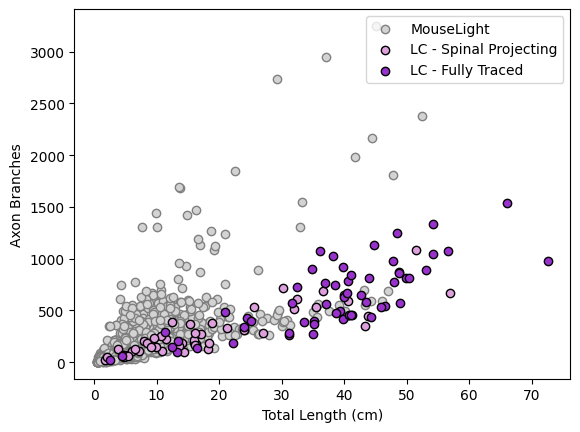

In [9]:
sns.scatterplot(sharedDF[sharedDF["isML"]],x = "Total Length (cm)", y = "Axon Branches", edgecolor = "gray", facecolor = "lightgray", linewidth = 1)
sns.scatterplot(sharedDF[sharedDF["isSpinalProjecting"] == True],x = "Total Length (cm)", y = "Axon Branches", edgecolor = "black", facecolor = "Plum", linewidth = 1)
sns.scatterplot(sharedDF[sharedDF["isSpinalProjecting"] == False],x = "Total Length (cm)", y = "Axon Branches", edgecolor = "black", facecolor = "DarkOrchid", linewidth = 1)
plt.legend(["MouseLight","LC - Spinal Projecting","LC - Fully Traced"])
# plt.savefig("../results/LC total length vs branch count.svg",dpi=300,bbox_inches='tight')
plt.savefig("../results/LC and Mouselight length vs branch count.svg",dpi=300,bbox_inches='tight')

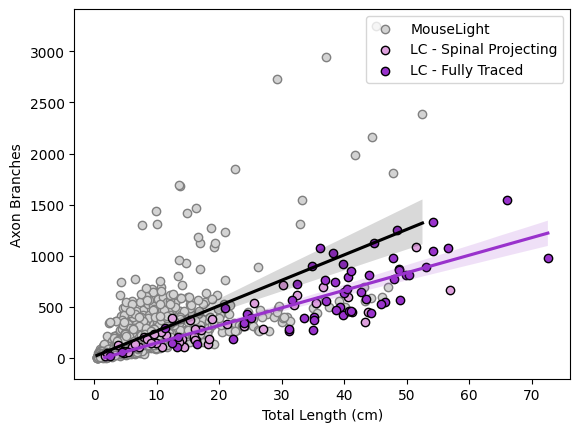

In [12]:
sns.scatterplot(sharedDF[sharedDF["isML"]],x = "Total Length (cm)", y = "Axon Branches", edgecolor = "gray", facecolor = "lightgray", linewidth = 1)
sns.scatterplot(sharedDF[sharedDF["isSpinalProjecting"] == True],x = "Total Length (cm)", y = "Axon Branches", edgecolor = "black", facecolor = "Plum", linewidth = 1)
sns.scatterplot(sharedDF[sharedDF["isSpinalProjecting"] == False],x = "Total Length (cm)", y = "Axon Branches", edgecolor = "black", facecolor = "DarkOrchid", linewidth = 1)
plt.legend(["MouseLight","LC - Spinal Projecting","LC - Fully Traced"])
sns.regplot(sharedDF[sharedDF["isML"]],x = "Total Length (cm)", y = "Axon Branches", color = "black", scatter = False)
sns.regplot(sharedDF[~sharedDF["isML"]],x = "Total Length (cm)", y = "Axon Branches", color = "DarkOrchid", scatter = False)
plt.savefig("../results/LC and Mouselight length vs branch count with regression and CI.svg",dpi=300,bbox_inches='tight')

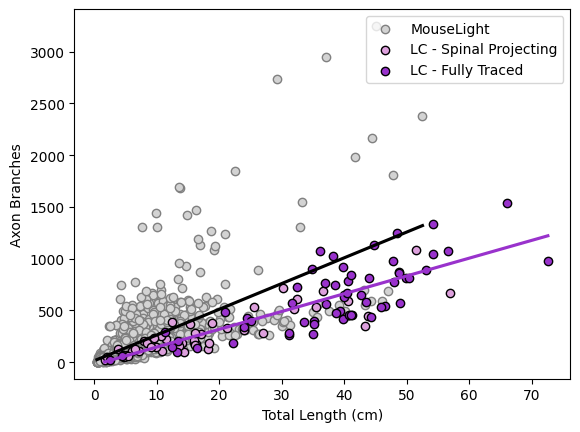

In [13]:
sns.scatterplot(sharedDF[sharedDF["isML"]],x = "Total Length (cm)", y = "Axon Branches", edgecolor = "gray", facecolor = "lightgray", linewidth = 1)
sns.scatterplot(sharedDF[sharedDF["isSpinalProjecting"] == True],x = "Total Length (cm)", y = "Axon Branches", edgecolor = "black", facecolor = "Plum", linewidth = 1)
sns.scatterplot(sharedDF[sharedDF["isSpinalProjecting"] == False],x = "Total Length (cm)", y = "Axon Branches", edgecolor = "black", facecolor = "DarkOrchid", linewidth = 1)
plt.legend(["MouseLight","LC - Spinal Projecting","LC - Fully Traced"])
sns.regplot(sharedDF[sharedDF["isML"]],x = "Total Length (cm)", y = "Axon Branches", color = "black", scatter = False, ci = None)
sns.regplot(sharedDF[~sharedDF["isML"]],x = "Total Length (cm)", y = "Axon Branches", color = "DarkOrchid", scatter = False, ci = None)
plt.savefig("../results/LC and Mouselight length vs branch count with regression no CI.svg",dpi=300,bbox_inches='tight')

In [14]:
from scipy import stats

In [23]:
# Perform linear regression to get R-value
slope, intercept, r_value, p_value, std_err = stats.linregress(sharedDF[~sharedDF["isML"]]["Total Length (cm)"], 
                                                               sharedDF[~sharedDF["isML"]]["Axon Branches"])
# Calculate R-squared
r_squared = r_value**2
print(f"slope : {slope}")
print(f"intercept : {intercept}")
print(f"R^2 : {r_squared}")
print(f"pval : {p_value}")

slope : 17.18270815307419
intercept : -25.690499915328417
R^2 : 0.7410753595334758
pval : 7.081526440810124e-33


In [21]:
# Perform linear regression to get R-value
slope, intercept, r_value, p_value, std_err = stats.linregress(sharedDF[sharedDF["isML"]]["Total Length (cm)"], 
                                                               sharedDF[sharedDF["isML"]]["Axon Branches"])
# Calculate R-squared
r_squared = r_value**2
print(f"slope : {slope}")
print(f"intercept : {intercept}")
print(f"R^2 : {r_squared}")
print(f"pval : {p_value}")

slope : 24.870250026567188
intercept : 13.653056172509736
R^2 : 0.4172703801547808
pval : 7.864598272952046e-146


In [ ]:
sns.regplot(sharedDF[sharedDF["isML"]],x = "Total Length (cm)", y = "Axon Branches", color = "black", scatter = False)
sns.regplot(sharedDF[~sharedDF["isML"]],x = "Total Length (cm)", y = "Axon Branches", color = "DarkOrchid", scatter = False)
# plt.savefig("../results/LC and Mouselight length vs branch count with regression and CI.svg",dpi=300,bbox_inches='tight')



<Axes: xlabel='Total Length (cm)', ylabel='Axon Branches'>

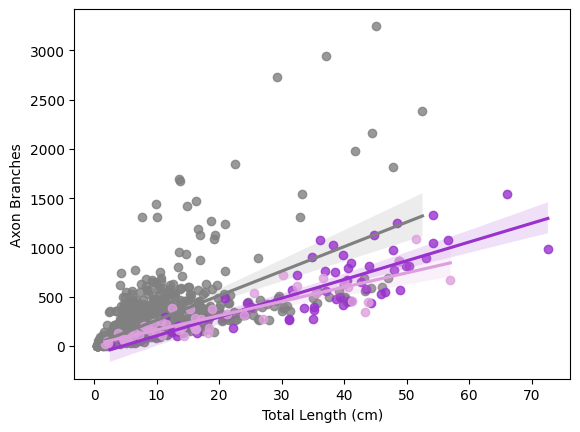

In [228]:
sns.regplot(sharedDF[sharedDF["isML"]],x = "Total Length (cm)", y = "Axon Branches", color = "gray")
sns.regplot(sharedDF[sharedDF["isSpinalProjecting"] == False],x = "Total Length (cm)", y = "Axon Branches", color = "DarkOrchid")
sns.regplot(sharedDF[sharedDF["isSpinalProjecting"] == True],x = "Total Length (cm)", y = "Axon Branches", color = "Plum")

In [239]:
from scipy import stats

# Assuming 'df' from the regplot example
slope, intercept, r_value, p_value, std_err = stats.linregress(sharedDF[sharedDF["isML"]]["Total Length (cm)"], sharedDF[sharedDF["isML"]]["Axon Branches"])

print(f"Slope: {slope}")
print(f"Intercept: {intercept}")
print(f"R-squared: {r_value**2}")

Slope: 24.870250026567188
Intercept: 13.653056172509736
R-squared: 0.4172703801547808


In [243]:
from scipy import stats

# Assuming 'df' from the regplot example
slope, intercept, r_value, p_value, std_err = stats.linregress(sharedDF[~sharedDF["isML"]]["Total Length (cm)"], sharedDF[~sharedDF["isML"]]["Axon Branches"])

print(f"Slope: {slope}")
print(f"Intercept: {intercept}")
print(f"R-squared: {r_value**2}")

Slope: 17.18270815307419
Intercept: -25.690499915328417
R-squared: 0.7410753595334758


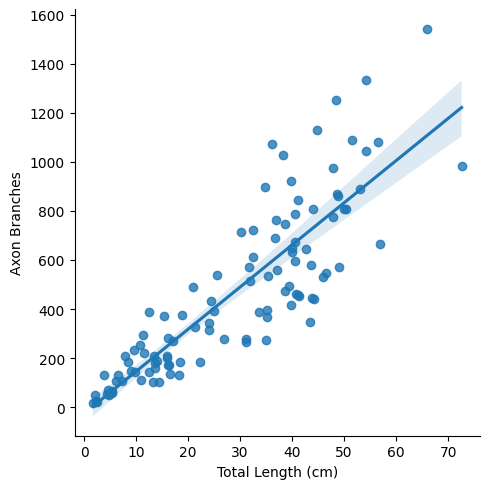

In [244]:
sns.lmplot(sharedDF[~sharedDF["isML"]],x = "Total Length (cm)", y = "Axon Branches")

## Perform stats

In [247]:
pip install pandas statsmodels

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 102.9 MB/s eta 0:00:0000:010:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.9/232.9 kB 59.7 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [248]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [317]:
# Establish dataframe for fitting
fitDF = sharedDF[~sharedDF["isML"]][["isSpinalProjecting", "Total Length (cm)","Axon Branches"]].copy() # Subset to just LC neurons
fitDF.loc[fitDF["isSpinalProjecting"] == True,"Group"] = "A" # Spinal projecting is group A
fitDF.loc[fitDF["isSpinalProjecting"] == False,"Group"] = "B" # Non spinal projecting is group B
fitDF = fitDF.drop(columns = "isSpinalProjecting")
fitDF = fitDF.rename(columns = {"Total Length (cm)":"DependentVar","Axon Branches":"Covariate"})
fitDF

,DependentVar,Covariate,Group
0,14.318932,103,A
1,72.567420,982,B
2,49.870732,809,B
3,39.771467,418,B
4,4.460401,56,B
...,...,...,...
103,9.654440,232,A
104,25.510407,538,A
105,9.106368,148,A
106,54.180260,1332,B


In [321]:
# Establish dataframe for fitting
fitDF = sharedDF[["isML", "Total Length (cm)","Axon Branches"]].copy()
fitDF.loc[fitDF["isML"],"Group"] = "A" # Mouselight group is A
fitDF.loc[~fitDF["isML"],"Group"] = "B" # LC group is B
fitDF = fitDF.drop(columns = "isML")
fitDF = fitDF.rename(columns = {"Total Length (cm)":"DependentVar","Axon Branches":"Covariate"})
fitDF

,DependentVar,Covariate,Group
0,14.318932,103,B
1,72.567420,982,B
2,49.870732,809,B
3,39.771467,418,B
4,4.460401,56,B
...,...,...,...
1330,6.958242,102,A
1331,6.196437,285,A
1332,6.148054,160,A
1333,3.703325,163,A


In [314]:
# ANCOVA model: DependentVar ~ Group + Covariate
model = smf.ols('DependentVar ~ Group + Covariate', data=fitDF).fit()

In [315]:
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           DependentVar   R-squared:                       0.617
Model:                            OLS   Adj. R-squared:                  0.616
Method:                 Least Squares   F-statistic:                     1072.
Date:                Mon, 22 Sep 2025   Prob (F-statistic):          3.95e-278
Time:                        23:56:54   Log-Likelihood:                -4322.6
No. Observations:                1335   AIC:                             8651.
Df Residuals:                    1332   BIC:                             8667.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      3.8927      0.221     17.612      0.0

In [325]:
model.pvalues

Intercept      1.401597e-62
Group[T.B]    1.038319e-107
Covariate     6.346891e-172
dtype: float64